# LoRA from Scratch — Medical-Domain QA Adaptation (Unified Notebook)

We implement LoRA (Low-Rank Adaptation) from scratch **without** libraries such as
`peft`, and analyze how the four axes **rank · target module · scaling · method**
affect performance and resource efficiency on medical QA
(MedMCQA / MedQA / PubMedQA). This single file contains everything: explanation →
from-scratch verification → training/evaluation → ablation → results and a
qualitative demo.

**Key message:** LoRA adapts to a domain by training only **0.1% of the parameters**
while preserving pretrained performance — in contrast to full fine-tuning (Full FT),
which collapses (catastrophic forgetting) at small scale.

> The `SMOKE` flag at the top selects the scale. `True` (default): 0.5B, small scale →
> a few minutes on free CPU/Colab. `False`: 1.5B, full scale → Colab GPU recommended.
> (`peft` is not used anywhere.)


In [1]:
# ── Environment setup ───────────────────────────────────────
import os, sys, pathlib
# Colab: clone the repo (skip if already present). Local: when run from notebooks/, move to the root.
if not pathlib.Path('lora').exists() and pathlib.Path('..', 'lora').exists():
    os.chdir('..')
if not pathlib.Path('lora').exists():
    !git clone https://github.com/SKKU-GEN-AI-LoRA/LoRA.git LoRA
    os.chdir('LoRA')
try:
    import google.colab  # noqa: F401  (install only on Colab; torch uses the default GPU build)
    !pip install -q transformers datasets accelerate matplotlib tqdm pyyaml pandas
except ImportError:
    pass

# Ensure the reports directory exists (it is git-ignored) so figure saving works on a fresh clone.
pathlib.Path('reports').mkdir(exist_ok=True)

# ── Scale selection ─────────────────────────────────────────
SMOKE = True   # True: 0.5B small scale (fast) / False: 1.5B full scale (Colab GPU)

def cfg(name):       # smoke/full config path
    return f'configs/smoke/{name}' if SMOKE else f'configs/{name}'
SWEEP_ROOT = 'checkpoints/smoke/sweeps' if SMOKE else 'checkpoints/sweeps'
BASE_CFG = cfg('lora_r8_qv.yaml')
BASE_DIR = 'checkpoints/smoke/lora_r8_qv' if SMOKE else 'checkpoints/lora_r8_qv'
print('SMOKE' if SMOKE else 'FULL', '| base config:', BASE_CFG, '| cwd:', pathlib.Path.cwd())

SMOKE | base config: configs/smoke/lora_r8_qv.yaml | cwd: /Users/injaeryou/Code/SKKU/2026-01/LLM_LoRa


## 1. LoRA Concept + From-Scratch Verification

$$W = W_0 + \tfrac{\alpha}{r} BA,\quad A\sim\mathcal{N}(0,\sigma^2),\ B=0$$

With $B=0$ initialization, $\Delta W=0$ at the start of training, so pretrained
performance is preserved exactly. Below we verify that our hand-written `LoRALinear`
(1) initially matches the base layer, and (2) follows exactly the
$W_0x + (\alpha/r)B(Ax)$ formula (pure torch, no libraries).

In [2]:
import torch, torch.nn as nn
from lora import LoRALinear

torch.manual_seed(0)
base = nn.Linear(16, 32)
lora = LoRALinear(base, r=4, alpha=8.0)
x = torch.randn(2, 16)
print('dW = 0 at init        ->', torch.allclose(lora(x), base(x)))

nn.init.normal_(lora.lora_B, std=0.1)  # make B non-trivial -> dW != 0
expected = base(x) + lora.scaling * (x @ lora.lora_A.t() @ lora.lora_B.t())
print('forward = W0x+(a/r)BAx ->', torch.allclose(lora(x), expected, atol=1e-5))

dW = 0 at init        -> True
forward = W0x+(a/r)BAx -> True


## 2. Model Injection Demo — Qwen2.5

We walk through the pretrained model, replace `q_proj` and `v_proj` with
`LoRALinear`, and mark only the LoRA parameters as trainable. We confirm the
trainable-parameter ratio is on the order of **0.1%**.

In [3]:
from transformers import AutoModelForCausalLM
from lora import inject_lora, mark_only_lora_as_trainable, count_parameters

mname = 'Qwen/Qwen2.5-0.5B-Instruct' if SMOKE else 'Qwen/Qwen2.5-1.5B-Instruct'
m = AutoModelForCausalLM.from_pretrained(mname, torch_dtype=torch.float32)
_, replaced = inject_lora(m, ['q_proj', 'v_proj'], r=8, alpha=16.0)
mark_only_lora_as_trainable(m)
tr, tot = count_parameters(m)
print(f'replaced modules: {len(replaced)}')
print(f'trainable: {tr:,} / {tot:,}  ({100*tr/tot:.4f}%)')
del m  # free memory

/Users/injaeryou/Code/SKKU/2026-01/LLM_LoRa/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


replaced modules: 48
trainable: 540,672 / 494,573,440  (0.1093%)


## 3. Training + Evaluation (baseline, real data)

We train LoRA (r=8, {q,v}) on MedMCQA and score three benchmarks. Evaluation uses
per-option log-likelihood argmax (a single forward pass, no generation), so it is
fast and reproducible.

In [4]:
!{sys.executable} scripts/train.py --config {BASE_CFG}

[lora] Qwen/Qwen2.5-0.5B-Instruct on mps (r=8, alpha=16.0, targets=['q_proj', 'v_proj'])


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


  trainable 540,672 / 494,573,440 (0.1093%)


  step 10/40  loss=1.1761  lr=1.75e-04


  step 20/40  loss=1.3467  lr=1.04e-04


...

eval/pubmedqa:  90%|█████████████████████████▏  | 36/40 [00:16<00:01,  2.19it/s]

eval/pubmedqa:  92%|█████████████████████████▉  | 37/40 [00:17<00:01,  2.25it/s]

eval/pubmedqa:  95%|██████████████████████████▌ | 38/40 [00:17<00:00,  2.29it/s]

eval/pubmedqa:  98%|███████████████████████████▎| 39/40 [00:17<00:00,  2.31it/s]

eval/pubmedqa: 100%|████████████████████████████| 40/40 [00:18<00:00,  2.18it/s]
  pubmedqa: acc=1.0000 (40/40)
  → saved checkpoints/smoke/lora_r8_qv/results.json


In [5]:
import json, pathlib
res = json.loads(pathlib.Path(f'{BASE_DIR}/results.json').read_text())['results']
print(f"trainable: {res['trainable_params']:,} ({res['trainable_pct']}%)")
print(f"final loss: {res.get('final_loss')}  train time: {res.get('train_time_sec')}s")
for ds, mr in res['eval'].items():
    print(f"  {ds:9s} acc = {mr['accuracy']:.4f} ({mr['correct']}/{mr['n']})")

trainable: 540,672 (0.1093%)
final loss: 1.2878  train time: 15.5s
  medmcqa   acc = 0.3000 (12/40)
  medqa     acc = 0.2750 (11/40)
  pubmedqa  acc = 1.0000 (40/40)


## Base model reference (zero-shot)

Evaluate the pretrained model with **no adaptation** — the baseline every result below is compared against (`d_<set>` columns and dotted lines = accuracy − base).

In [6]:
zdir = 'checkpoints/smoke/zeroshot' if SMOKE else 'checkpoints/zeroshot'
if not pathlib.Path(f'{zdir}/results.json').exists():
    !{sys.executable} scripts/train.py --config {cfg('zeroshot.yaml')}
BASE = {ds: m['accuracy']
        for ds, m in json.loads(pathlib.Path(f'{zdir}/results.json').read_text())['results']['eval'].items()}
print('base (zero-shot) accuracy:', {k: round(v, 4) for k, v in BASE.items()})

[zeroshot] Qwen/Qwen2.5-0.5B-Instruct on mps (r=8, alpha=16.0, targets=['q_proj', 'v_proj'])


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


  trainable 0 / 494,032,768 (0.0000%)


eval/medmcqa:   0%|                                      | 0/40 [00:00<?, ?it/s]

eval/medmcqa:   2%|▊                             | 1/40 [00:00<00:12,  3.05it/s]

...

eval/pubmedqa:  92%|█████████████████████████▉  | 37/40 [00:17<00:01,  2.19it/s]

eval/pubmedqa:  95%|██████████████████████████▌ | 38/40 [00:18<00:00,  2.21it/s]

eval/pubmedqa:  98%|███████████████████████████▎| 39/40 [00:18<00:00,  2.25it/s]

eval/pubmedqa: 100%|████████████████████████████| 40/40 [00:18<00:00,  2.11it/s]
  pubmedqa: acc=0.9500 (38/40)
  → saved checkpoints/smoke/zeroshot/results.json


base (zero-shot) accuracy: {'medmcqa': 0.375, 'medqa': 0.25, 'pubmedqa': 0.95}


## 4. Rank Sweep (RQ1)

rank $r \in \{1,4,8,16\}$. Trainable parameters grow linearly with rank; we look at
where accuracy saturates (i.e., the point at which a low rank is sufficient).
(Reuses sweep results if available.)

In [7]:
d = f'{SWEEP_ROOT}/rank'
if pathlib.Path(f'{d}/results.json').exists():
    print('cached ->', d)
else:
    !{sys.executable} eval/sweep.py --sweep {cfg('sweep_rank.yaml')}

cached -> checkpoints/smoke/sweeps/rank


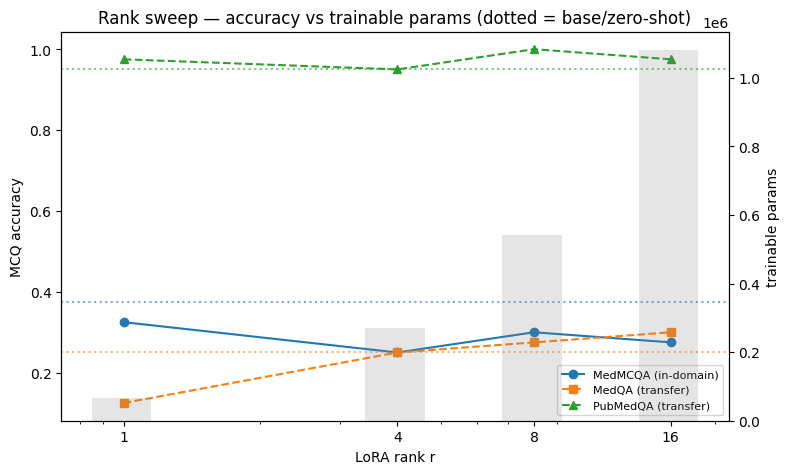

,name,r,alpha,trainable_pct,acc_medmcqa,acc_medqa,acc_pubmedqa,train_time_sec,d_medmcqa,d_medqa,d_pubmedqa
0,r1,1,2.0,0.0137,0.325,0.125,0.975,14.7,-0.050,-0.125,0.025
1,r4,4,8.0,0.0547,0.250,0.250,0.950,24.5,-0.125,0.000,0.000
2,r8,8,16.0,0.1093,0.300,0.275,1.000,31.7,-0.075,0.025,0.050
3,r16,16,32.0,0.2184,0.275,0.300,0.975,30.4,-0.100,0.050,0.025


In [8]:
import matplotlib.pyplot as plt
rows = sorted(json.loads(pathlib.Path(f'{SWEEP_ROOT}/rank/results.json').read_text()), key=lambda r: r['r'])
ranks = [r['r'] for r in rows]
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xscale('log'); ax1.set_xticks(ranks); ax1.set_xticklabels(ranks)
ax1.plot(ranks, [r['acc_medmcqa'] for r in rows], 'o-', color='C0', label='MedMCQA (in-domain)')
ax1.plot(ranks, [r.get('acc_medqa') for r in rows], 's--', color='C1', label='MedQA (transfer)')
ax1.plot(ranks, [r.get('acc_pubmedqa') for r in rows], '^--', color='C2', label='PubMedQA (transfer)')
for ds, c in [('medmcqa','C0'), ('medqa','C1'), ('pubmedqa','C2')]:
    ax1.axhline(BASE[ds], color=c, ls=':', alpha=0.6)  # base (zero-shot) reference
ax1.set_xlabel('LoRA rank r'); ax1.set_ylabel('MCQ accuracy'); ax1.legend(loc='lower right', fontsize=8)
ax2 = ax1.twinx()
ax2.bar(ranks, [r['trainable_params'] for r in rows], width=[r*0.3 for r in ranks], alpha=0.2, color='gray')
ax2.set_ylabel('trainable params')
plt.title('Rank sweep — accuracy vs trainable params (dotted = base/zero-shot)')
plt.tight_layout(); plt.savefig('reports/fig_rank_sweep.png', dpi=150); plt.show()

import pandas as pd
df = pd.DataFrame(rows)[['name','r','alpha','trainable_pct','acc_medmcqa','acc_medqa','acc_pubmedqa','train_time_sec']]
for ds in ['medmcqa','medqa','pubmedqa']:
    df[f'd_{ds}'] = (df[f'acc_{ds}'] - BASE[ds]).round(3)  # delta vs base
df

## 5. Target Module Sweep (RQ2)

{q,v} / {q,k,v,o} / {q,k,v,o}+MLP. We examine per-parameter efficiency (Pareto) and
the in-domain vs. transfer balance.

In [9]:
d = f'{SWEEP_ROOT}/module'
if pathlib.Path(f'{d}/results.json').exists():
    print('cached ->', d)
else:
    !{sys.executable} eval/sweep.py --sweep {cfg('sweep_module.yaml')}

cached -> checkpoints/smoke/sweeps/module


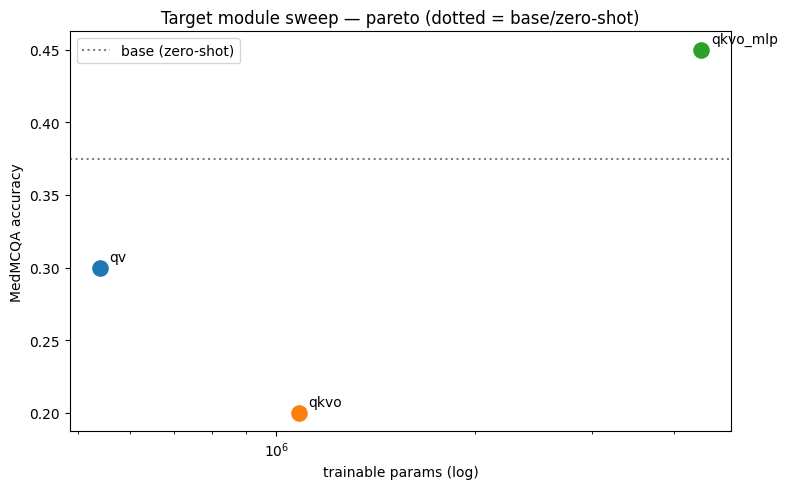

,name,target_modules,trainable_pct,acc_medmcqa,acc_medqa,acc_pubmedqa,d_medmcqa,d_medqa,d_pubmedqa
0,qv,q_proj+v_proj,0.1093,0.30,0.275,1.000,-0.075,0.025,0.050
1,qkvo,q_proj+k_proj+v_proj+o_proj,0.2184,0.20,0.225,0.825,-0.175,-0.025,-0.125
2,qkvo_mlp,q_proj+k_proj+v_proj+o_proj+gate_proj+up_proj+...,0.8826,0.45,0.200,0.775,0.075,-0.050,-0.175


In [10]:
rows = json.loads(pathlib.Path(f'{SWEEP_ROOT}/module/results.json').read_text())
fig, ax = plt.subplots(figsize=(8, 5))
for r in rows:
    ax.scatter(r['trainable_params'], r['acc_medmcqa'], s=120)
    ax.annotate(r['name'], (r['trainable_params'], r['acc_medmcqa']), xytext=(7, 5), textcoords='offset points')
ax.axhline(BASE['medmcqa'], color='gray', ls=':', label='base (zero-shot)')  # base reference
ax.set_xscale('log'); ax.set_xlabel('trainable params (log)'); ax.set_ylabel('MedMCQA accuracy')
ax.set_title('Target module sweep — pareto (dotted = base/zero-shot)'); ax.legend()
plt.tight_layout(); plt.savefig('reports/fig_module_sweep.png', dpi=150); plt.show()
df = pd.DataFrame(rows)[['name','target_modules','trainable_pct','acc_medmcqa','acc_medqa','acc_pubmedqa']]
for ds in ['medmcqa','medqa','pubmedqa']:
    df[f'd_{ds}'] = (df[f'acc_{ds}'] - BASE[ds]).round(3)  # delta vs base
df

## 6. Scaling Sweep (RQ3)

r=8 fixed, $\alpha/r \in \{0.5, 1, 2\}$. Scaling acts like an effective learning rate
for $\Delta W$.

In [11]:
d = f'{SWEEP_ROOT}/alpha'
if pathlib.Path(f'{d}/results.json').exists():
    print('cached ->', d)
else:
    !{sys.executable} eval/sweep.py --sweep {cfg('sweep_alpha.yaml')}
rows = json.loads(pathlib.Path(f'{SWEEP_ROOT}/alpha/results.json').read_text())
df = pd.DataFrame(rows)[['name','alpha','scaling','acc_medmcqa','acc_medqa','acc_pubmedqa','final_loss']]
for ds in ['medmcqa','medqa','pubmedqa']:
    df[f'd_{ds}'] = (df[f'acc_{ds}'] - BASE[ds]).round(3)  # delta vs base
df

cached -> checkpoints/smoke/sweeps/alpha


,name,alpha,scaling,acc_medmcqa,acc_medqa,acc_pubmedqa,final_loss,d_medmcqa,d_medqa,d_pubmedqa
0,scale0p5,4.0,0.5,0.375,0.325,0.950,1.3138,0.000,0.075,0.000
1,scale1,8.0,1.0,0.250,0.275,0.975,1.2848,-0.125,0.025,0.025
2,scale2,16.0,2.0,0.300,0.275,1.000,1.2878,-0.075,0.025,0.050


## 7. LoRA vs Full FT vs Zero-shot (RQ4)

We compare the three methods on the same data and seed. **Key result**: LoRA adapts
with 0.1% of the parameters, while Full FT collapses at small scale (catastrophic
forgetting).

In [12]:
d = f'{SWEEP_ROOT}/method'
if pathlib.Path(f'{d}/results.json').exists():
    print('cached ->', d)
else:
    !{sys.executable} eval/sweep.py --sweep {cfg('sweep_method.yaml')}

cached -> checkpoints/smoke/sweeps/method


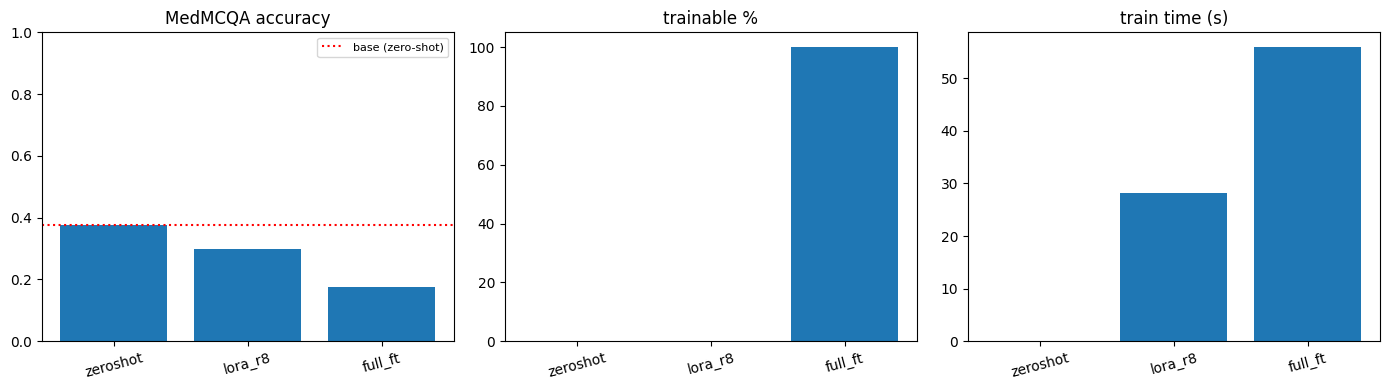

,name,method,trainable_pct,acc_medmcqa,acc_medqa,acc_pubmedqa,train_time_sec,d_medmcqa,d_medqa,d_pubmedqa
0,zeroshot,zeroshot,0.0000,0.375,0.250,0.950,NaN,0.000,0.000,0.000
1,lora_r8,lora,0.1093,0.300,0.275,1.000,28.2,-0.075,0.025,0.050
2,full_ft,full,100.0000,0.175,0.175,0.325,55.9,-0.200,-0.075,-0.625


In [13]:
rows = sorted(json.loads(pathlib.Path(f'{SWEEP_ROOT}/method/results.json').read_text()),
              key=lambda r: {'zeroshot':0,'lora_r8':1,'full_ft':2}.get(r['name'], 9))
names = [r['name'] for r in rows]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(names, [r['acc_medmcqa'] for r in rows]); axes[0].set_title('MedMCQA accuracy'); axes[0].set_ylim(0, 1)
axes[0].axhline(BASE['medmcqa'], color='red', ls=':', label='base (zero-shot)'); axes[0].legend(fontsize=8)
axes[1].bar(names, [r['trainable_pct'] for r in rows]); axes[1].set_title('trainable %')
axes[2].bar(names, [r.get('train_time_sec') or 0 for r in rows]); axes[2].set_title('train time (s)')
for ax in axes: ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.savefig('reports/fig_method_compare.png', dpi=150); plt.show()
df = pd.DataFrame(rows)[['name','method','trainable_pct','acc_medmcqa','acc_medqa','acc_pubmedqa','train_time_sec']]
for ds in ['medmcqa','medqa','pubmedqa']:
    df[f'd_{ds}'] = (df[f'acc_{ds}'] - BASE[ds]).round(3)  # delta vs base
df

## 8. In-domain vs Transfer

MedMCQA (in-domain) vs. MedQA/PubMedQA (transfer) per rank — we look at the
generalization of domain adaptation.

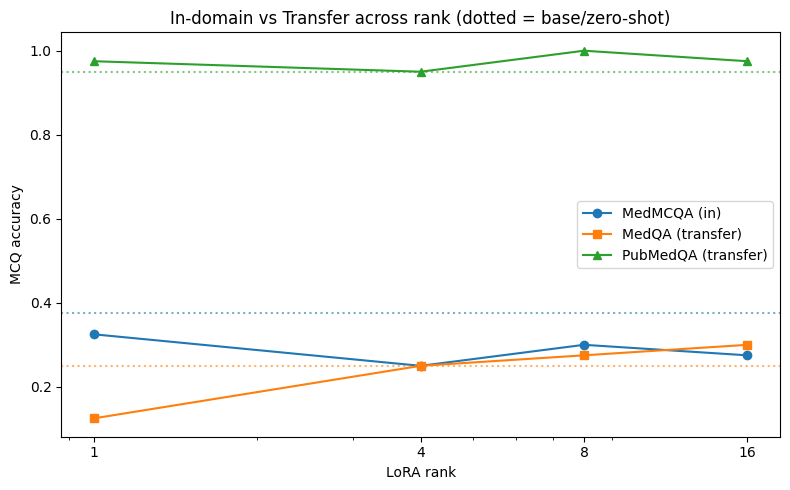

In [14]:
rows = sorted(json.loads(pathlib.Path(f'{SWEEP_ROOT}/rank/results.json').read_text()), key=lambda r: r['r'])
ranks = [r['r'] for r in rows]
fig, ax = plt.subplots(figsize=(8, 5))
for col, mk, lbl, c in [('acc_medmcqa','o','MedMCQA (in)','C0'),
                        ('acc_medqa','s','MedQA (transfer)','C1'),
                        ('acc_pubmedqa','^','PubMedQA (transfer)','C2')]:
    ax.plot(ranks, [r.get(col) for r in rows], marker=mk, label=lbl, color=c)
    ax.axhline(BASE[col.replace('acc_','')], color=c, ls=':', alpha=0.6)  # base reference
ax.set_xscale('log'); ax.set_xticks(ranks); ax.set_xticklabels(ranks)
ax.set_xlabel('LoRA rank'); ax.set_ylabel('MCQ accuracy'); ax.legend()
ax.set_title('In-domain vs Transfer across rank (dotted = base/zero-shot)')
plt.tight_layout(); plt.savefig('reports/fig_transfer.png', dpi=150); plt.show()

## 9. Qualitative Comparison — Zero-shot vs LoRA

For the same clinical question, we compare the responses of the pretrained model
as-is (zero-shot) and the LoRA-adapted model.

In [15]:
DEMO_Q = ('A 65-year-old man presents with chest pain radiating to the left arm. '
          'ECG shows ST-segment elevation in leads II, III, and aVF. '
          'Which coronary artery is most likely occluded?')
print('=== zero-shot ===')
!{sys.executable} scripts/generate.py --config {BASE_CFG} --question "$DEMO_Q" --max-new-tokens 120
print('\n=== LoRA ===')
!{sys.executable} scripts/generate.py --config {BASE_CFG} --ckpt {BASE_DIR}/lora.pt --question "$DEMO_Q" --max-new-tokens 120

=== zero-shot ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!



=== zero-shot response ===
The symptoms described—chest pain radiating to the left arm and ST-segment elevation on an electrocardiogram (ECG) in leads II, III, and aVF—are consistent with angina pectoris, which can be caused by various coronary artery occlusions.

Given that the patient has been diagnosed with angina pectoris, it is highly probable that the occlusion affecting the coronary arteries leading to the heart muscle is located in the anterior descending branch of the left circumflex coronary artery (LCA). This branch supplies blood to the lateral wall of the left ventricle,



=== LoRA ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!



=== LoRA response ===
The symptoms described suggest that the patient may have aortic dissection or aneurysm of the abdominal aorta. These conditions can cause significant chest pain radiating to the left arm due to the obstruction of blood flow to the heart muscle.

To determine which coronary artery is most likely occluded, we need to consider the specific location of the aortic dissection or aneurysm:

1. **Aortic Dissection**: This condition involves the rupture of the aortic wall, often causing aortic dissection (a tear in the inner layer of the aorta). The symptoms typically include


## 10. Conclusion

- **From-scratch implementation**: `LoRALinear`, injection, merging, training loop,
  and sweep written without `peft`; the sanity checks above confirm the formula and
  merge correctness.
- **RQ1 rank**: efficiency is linear in rank; performance saturates at low rank (at
  this scale).
- **RQ2 module**: {q,v} is the balance point for per-parameter efficiency and transfer
  stability; +MLP raises in-domain but lowers transfer.
- **RQ3 scaling**: loss is lowest at alpha/r = 1–2 (sufficient adaptation); 0.5 under-adapts.
- **RQ4 method**: LoRA adapts with 0.1% of the parameters and no forgetting, while
  Full FT collapses at small scale.
- On the efficiency axes (parameters and time), LoRA's advantage holds decisively
  regardless of scale.

Set `SMOKE=False` with a Colab GPU to reproduce the 1.5B full-scale curves.